# 基于英特尔 OpenVINO 的本地文旅商家智能助手 - 可复现 Notebook

## 📝 使用说明
本 Notebook 展示了项目的核心功能（如需定制化使用，更建议使用本notebook尾部附带的GUI）
本 Notebook 可无缝在ModelScope的灵感流运行（已测验）
如需转为本地设备，则只需调整其中的cd命令的路径

**快速体验：**

1. 初始化环境并加载演示案例
2. 体验六大核心功能
3. 查看生成的海报图片
4. 与商家小助手对话
5. 启动完整 GUI 界面

---
## 环境安装

In [ ]:
!git clone https://github.com/go-lisa/2B-Marketing.git

In [ ]:
!pip install -r requirements.txt

## 多模态大模型安装

In [ ]:
%cd /mnt/workspace

In [ ]:
!mkdir lab1-multimodal-vlm
!mkdir lab4-image-generation

In [ ]:
from pathlib import Path

model_dir = Path("lab1-multimodal-vlm/Qwen3-VL-4B-Instruct-int4-ov")

if not model_dir.exists():
    from modelscope import snapshot_download
    snapshot_download("snake7gun/Qwen3-VL-4B-Instruct-int4-ov", local_dir=str(model_dir))
    print(f"模型已下载到: {model_dir}")
else:
    print(f"模型已存在: {model_dir}，跳过下载")

In [ ]:
model_dir = Path("lab4-image-generation/Z-Image-Turbo-int4-ov")

if not model_dir.exists():
    from modelscope import snapshot_download
    snapshot_download("snake7gun/Z-Image-Turbo-int4-ov", local_dir=str(model_dir))
    print(f"模型已下载到: {model_dir}")
else:
    print(f"模型已存在: {model_dir}，跳过下载")

---
## 环境导入和初始化

In [ ]:
%cd /mnt/workspace/2B-Marketing

In [1]:
# 导入核心模块（复用现有代码）
import sys
from pathlib import Path

# 确保在 2B-Marketing 目录下运行
project_root = Path(".").resolve()
if not (project_root / "state_manager.py").exists():
    print("⚠️  请在 2B-Marketing/ 目录下运行此 Notebook")
    sys.exit(1)

# 导入项目模块
from state_manager import global_context, create_demo_case
from api_service_local import llm_service, wanx_service
from prompt_templates import PromptTemplates

print("✅ 模块导入成功")
print(f"📍 项目路径: {project_root}")

Multiple distributions found for package optimum. Picked distribution: optimum
D:\work\OpenVINO\modelscope-workshop\ov_workshop\lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


正在加载 Qwen3-VL 模型...
模型路径: D:\work\OpenVINO\modelscope-workshop\lab1-multimodal-vlm\Qwen3-VL-4B-Instruct-int4-ov
推理设备: CPU


The tokenizer you are loading from 'D:\work\OpenVINO\modelscope-workshop\lab1-multimodal-vlm\Qwen3-VL-4B-Instruct-int4-ov' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


✅ Qwen3-VL 模型加载完成
正在加载 Z-Image-Turbo 模型...
模型路径: D:\work\OpenVINO\modelscope-workshop\lab4-image-generation\Z-Image-Turbo-int4-ov
推理设备: CPU
✅ Z-Image-Turbo 模型加载完成
✅ 模块导入成功
📍 项目路径: D:\work\OpenVINO\modelscope-workshop\code


---
## 加载演示案例（商家数字档案）

In [2]:
# 加载预设的演示案例
demo_case_name = "西湖绸伞店"  # 可选：西湖绸伞店、满觉陇民宿、龙井茶庄

case_data = create_demo_case(demo_case_name)

# 更新全局上下文
summary = global_context.update_profile(
    shop_name=case_data["shop_name"],
    location=case_data["location"],
    opening_date=case_data["opening_date"],
    features=case_data["features"],
    weather=case_data["weather"],
    holiday=case_data["holiday"],
    inventory_status=case_data["inventory_status"],
    target_audience=case_data["target_audience"]
)

print("=" * 60)
print("📋 商家数字档案已加载")
print("=" * 60)
print(summary)
print("\n✅ 可以开始使用各智能引擎！")

📋 商家数字档案已加载
【商家档案】
店铺名称：西湖绸伞工艺坊
地理位置：杭州市西湖区河坊街 128 号
开业时间：2018 年 5 月
核心特色：非遗传承、宋韵文化、手工技艺、文创产品
今日天气：小雨
节假日：端午节
营业状态：库存充足，周末客流高峰
目标客群：文化体验爱好者、亲子家庭
已上传文档：0 份

✅ 可以开始使用各智能引擎！


---
## 文化内容引擎 - 生成文化故事

In [3]:
# 测试商品名称
product_name = "西湖绸伞·经典款"
story_type = "游客版"  # 可选：游客版、专家版

print(f"🎨 正在为 '{product_name}' 生成{story_type}文化故事...")
print("-" * 60)

# 调用文化内容引擎
context = global_context.to_prompt_context()
system_prompt = PromptTemplates.get_content_engine_prompt(context)

user_prompt = f"""请为商品/景点"{product_name}"生成{story_type}文化故事。

要求：
1. 深入挖掘产品背后的历史文化、工艺细节、情感寓意
2. 结合我店的特色和地理位置，突出独特性
3. {story_type}版本要{"通俗易懂、引发情感共鸣" if story_type == "游客版" else "专业深度、详细工艺细节"}
4. 字数：500-800 字"""

result = llm_service.generate(system_prompt, user_prompt)

# 保存结果
global_context.save_engine_result("content", {"type": "故事", "content": result})

print(result)
print("\n✅ 文化故事生成完成")

🎨 正在为 '西湖绸伞·经典款' 生成游客版文化故事...
------------------------------------------------------------
【游客版·西湖绸伞·经典款 · 文化故事】

你见过在西湖边，一把伞能“撑起”千年风雅吗？

在杭州河坊街128号的“西湖绸伞·经典款”，每一把伞都是时光的信物——它不只遮雨，更是一场温柔的宋韵回响。它从宋朝的江南烟雨里走来，带着“苏堤春晓”“断桥残雪”的诗意，也藏着“西湖十景”里最动人的那一抹柔光。

这把伞，是用杭州本地的“杭绸”为骨、以“湖丝”为魂，一针一线，手作成形。匠人用的是“三寸针、七道工序”的古法，从选绸、裁料、绣花、上金、收口、收边，到最后的“伞骨嵌银丝”，全靠一双巧手与百年经验。你若细看，伞面上那朵“西湖荷”或“断桥柳”，每一笔都像在写一首小诗——不是机器能复制的，是匠人用生命在织的。

它为何叫“经典款”？因为它是“宋韵美学”的化身。宋代文人爱伞，不仅为遮雨，更以伞为“文心”——“雨中撑伞，是文人雅士的风骨；伞下观景，是江南诗意的栖居”。你若在西湖边撑开它，不只挡雨，更是在“宋朝的雨里，与苏轼、白居易、李清照，共饮一盏茶”。

河坊街是“杭州的文脉之根”，而西湖绸伞，是这条文脉的“袖珍版”。它不只是一把伞，是“杭州人记忆的温柔回响”——你撑开它，是走进了“南宋临安”的市井烟火，是触到了“雷峰夕照”的柔光，是听到了“断桥上，游人说笑”的低语。

它不贵，却贵在“有故事”。它不炫，却最懂“江南情”。你若在西湖边，为爱人、为朋友、为自己的心事，撑开一把“西湖绸伞”，它会替你把“雨”变成“诗”，把“路”变成“画”，把“西湖”变成“你心里的江南”。

撑伞的那一刻，你不是游客，你是“宋朝的过客”，是“西湖的主人”，是“杭州的诗人”。你撑的，不只是伞，是“一寸光阴，一寸柔情”。

——在河坊街128号，等你，撑开属于你的“宋韵雨幕”。

（字数：798）

✅ 文化故事生成完成


---
## 文化内容引擎 - 多语言翻译

In [4]:
# 使用上一步生成的故事内容进行翻译
target_language = "英文"

print(f"🌍 正在将文化故事翻译成{target_language}...")
print("-" * 60)

# 提取上一步的故事内容（简化示例，实际使用时可以传入具体内容）
sample_content = """西湖绸伞，又称"西湖纸伞"，是杭州传统手工艺品的代表之一。
始于南宋时期，已有800多年历史。伞面采用特制桑皮纸，
伞骨选用江南特产淡竹，经过72道工序精心制作而成。
每一把绸伞都承载着江南水乡的诗意与浪漫。"""

context = global_context.to_prompt_context()
system_prompt = PromptTemplates.get_content_engine_prompt(context)

user_prompt = f"""请将以下内容翻译成{target_language}，并进行文化背景解释：

原文：
{sample_content}

要求：
1. 不仅要翻译字面意思，更要解释文化内涵
2. 对于特有文化概念（如非遗技艺、历史典故），提供简短的背景说明
3. 给出商家使用外文内容的真实场景指引
4. 格式：先翻译，再解释关键文化概念，最后给出店员的实践指导
"""

translation_result = llm_service.generate(system_prompt, user_prompt)

print(translation_result)
print("\n✅ 多语言翻译完成")

🌍 正在将文化故事翻译成英文...
------------------------------------------------------------
**English Translation:**

**Wu Lake Silk Umbrella (also known as “Wu Lake Paper Umbrella”)** is one of Hangzhou’s most emblematic traditional handcrafts — a poetic vessel of江南水乡 (Southern Jiangnan water town) romance, whispered into being since the Southern Song Dynasty, over 800 years ago.  
The canopy is crafted from specially treated桑皮纸 (mulberry-bark paper), while the ribs are hand-selected淡竹 (light bamboo) from the Jiangnan region — painstakingly assembled through 72 meticulous stages of artisanship.  
Each umbrella carries not merely function, but the soul of Jiangnan’s seasonal mist, moonlit canals, and whispered love stories — a living echo of the region’s cultural heartbeat.

—

**Key Cultural Concepts Explained:**

1. **Wu Lake Silk Umbrella (西湖绸伞)**  
   — A UNESCO-recognized intangible cultural heritage (非遗) item from Hangzhou, symbolizing the “宋韵” (Song Dynasty aesthetic) — refined elegance, ink

---
## 文化内容引擎 - 短视频脚本

In [5]:
product_name = "西湖绸伞·经典款"

print(f"🎬 正在为 '{product_name}' 创作短视频脚本...")
print("-" * 60)

context = global_context.to_prompt_context()
system_prompt = PromptTemplates.get_content_engine_prompt(context)

user_prompt = f"""请为商品/景点"{product_name}"创作一个 60 秒短视频脚本。

要求包含：
1. 分镜描述（画面内容、拍摄角度）
2. 旁白文案（每句台词和对应时间）
3. 背景音乐建议（风格、情绪）
4. 字幕文案（重点金句）
5. 开头 3 秒必须有吸引力，结尾有行动号召

格式示例：
【0-3 秒】画面：特写镜头... 旁白：... BGM：...
【4-15 秒】画面：..."""

script_result = llm_service.generate(system_prompt, user_prompt)
global_context.save_engine_result("content", {"type": "视频脚本", "content": script_result})

print(script_result)
print("\n✅ 短视频脚本生成完成")

🎬 正在为 '西湖绸伞·经典款' 创作短视频脚本...
------------------------------------------------------------
【0-3 秒】  
画面：特写镜头 —— 一把西湖绸伞静静躺在河坊街古色古香的木桌上，伞面轻颤，映出西湖水影，阳光穿过伞骨投下细密金线。  
旁白：（低沉温润）“一伞一湖，一寸宋韵。”  
BGM：古筝轻拨 + 略带水波感的箫音，空灵悠远，带点江南烟雨的静谧感。  
字幕（金色烫金字体）：西湖绸伞 · 经典款 · 非遗传承 · 128号河坊街  

【4-15 秒】  
画面：镜头缓缓上移，展现伞面“苏堤春晓”纹样，细密金线勾勒出苏堤柳浪，背景虚化为西湖边的断桥残雪与雷峰塔影。  
旁白：（柔声讲述）“它不只是一把伞，是宋人笔下‘雨打芭蕉’的诗意，是岳飞笔下‘还我河山’的豪情，是西湖边，一缕未散的烟雨。”  
BGM：古琴轻拨渐入，加入轻柔的鼓点，情绪由静转柔，带点历史纵深感。  
字幕（中英双语）：  
“苏堤春晓 · 雷峰夕照 · 一伞承千年风骨”  
（英文）“One Umbrella, a Thousand Years of Wind and Bones”  

【16-30 秒】  
画面：特写 —— 工匠手指轻抚伞骨，用细如发丝的金线缠绕伞骨，镜头拉远，展现整个伞面在灯光下泛着柔光，如水墨晕染。  
旁白：（沉稳如述）“每一根伞骨，都承着南宋匠人的手温；每一道纹路，都藏著西湖的晨雾与晚霞。”  
BGM：古筝音色渐强，加入细微的“叮咚”水声模拟雨滴，情绪渐入深邃。  
字幕（书法体）：  
“手作 · 128号 · 一伞一匠 · 一寸宋韵”  

【31-45 秒】  
画面：镜头切换至“河坊街·西湖绸伞工坊”内部，老匠人正将伞面覆于伞骨，轻声吟唱古调，背景是满墙“苏堤春晓”“断桥残雪”等宋画复刻图样。  
旁白：（略带敬意）“它不为遮雨，只为承托一段江南的魂魄——在西湖的风里，它记得你，也记得自己。”  
BGM：加入古琴与箫的合奏，情绪由深沉转为温润，带点“江湖归处”的诗意。  
字幕（手写体）：  
“非卖品 · 非遗之伞 · 一伞一故事 · 一伞一江湖”  

【46-55 秒】  
画面：镜头拉远，伞被轻抬，伞面如画，映出西湖全景，背景是雷峰塔、三潭印月、苏堤春柳，镜头

---
## 体验策划引擎 - 生成活动方案

In [6]:
activity_theme = ""  # 留空让 AI 自主创意，或指定主题如"端午文化节"

print("🎯 正在生成店内微活动方案...")
print("-" * 60)

context = global_context.to_prompt_context()
system_prompt = PromptTemplates.get_planning_engine_prompt(context)

user_prompt = f"""请设计一个店内微活动方案。
{"活动主题：" + activity_theme if activity_theme else "请根据当前天气和节假日自主创意"}

要求：
1. 充分利用在地资源和现有场地
2. 强调文化体验和互动参与
3. 方案要切实可行，成本低
4. 输出完整的活动策划包"""

activity_result = llm_service.generate(system_prompt, user_prompt)
global_context.save_engine_result("planning", {"type": "活动方案", "content": activity_result})

print(activity_result)
print("\n✅ 活动方案生成完成")

🎯 正在生成店内微活动方案...
------------------------------------------------------------
🌿 活动主题：  
**“雨打江南，伞承宋韵——西湖绸伞·端午祈福体验日”**

——让雨声为伴，让宋韵入心，亲手织就一柄“端午之伞”，护佑家宅安康

---

### 🌟 活动亮点（5大核心体验）：

1. **“雨中宋韵”沉浸式导览** —— 以雨为媒，讲述南宋“雨巷”与“伞文化”故事，唤醒对西湖水韵的感知。
2. **“五毒驱邪·伞绘端午”手作工坊** —— 亲手绘制“五毒避邪”纹样，结合端午节俗，打造专属“祈福伞”。
3. **“伞下童言”亲子互动区** —— 亲子共绘“伞中童趣”，配以“小伞人”纸偶，寓教于乐。
4. **“宋韵茶香·伞下品茗”** —— 以雨天为由，推出“雨中茶席”，配以宋式茶点，体验“伞下闲谈”之雅。
5. **“伞影留痕·非遗传承墙”** —— 顾客可留名“伞上诗”或“伞下愿”，打造“雨中许愿墙”，强化文化记忆。

---

### 🕰️ 流程时间表（总时长：90分钟）

| 时间段 | 活动内容 | 说明 |
|--------|----------|------|
| 10:00–10:15 | 开场导览 & 签到 | 雨中宋韵故事开场，签到墙+雨伞许愿卡领取 |
| 10:15–10:45 | “五毒避邪·伞绘端午”手作 | 10分钟讲解+30分钟实操（分组+指导） |
| 10:45–11:15 | 亲子互动区“伞中童趣” | 纸偶互动+亲子绘图（15分钟+15分钟） |
| 11:15–11:30 | “伞下品茗”茶席体验 | 雨天特供“宋式雨茶”+宋瓷茶盏+伞下茶席布置 |
| 11:30–11:50 | “伞影留痕·非遗传承墙” | 书写/留言+合影墙+非遗传承人寄语 |
| 11:50–12:00 | 雨中谢幕 & 互动抽奖 | 送“伞下小福”纪念品+合影留念 |

---

### 🛒 所需物料清单（成本估算：¥350以内）

| 物料 | 数量 | 成本（¥） | 说明 |
|------|------|------------|------|
| 伞绘模板纸+彩笔+胶水 | 20套 | 80 | 预制模板+彩笔（可复用） |
| 亲子纸偶+画纸 | 10套 |

---
## 口碑管理引擎 - 评价分析

In [7]:
# 模拟一条游客评价
review_text = """昨天去了这家店，环境还不错，但是服务员态度有点冷淡。
我问了几个关于产品的问题，回答得很敷衍。
不过产品本身质量还可以，就是感觉缺乏文化讲解。
希望店家能加强员工培训吧。"""

print("💬 正在分析游客评价...")
print("-" * 60)
print(f"评价内容：\n{review_text}\n")
print("-" * 60)

context = global_context.to_prompt_context()
system_prompt = PromptTemplates.get_operation_engine_prompt(context)

user_prompt = f"""请分析以下游客评价，并提供回复和整改建议：

评价内容：
{review_text}

要求：
1. 提取情感和关键问题
2. 生成 2-3 个不同风格的高情商回复
3. 提供具体可执行的整改建议（低成本）
4. 体现真诚和专业"""

review_result = llm_service.generate(system_prompt, user_prompt)
global_context.save_engine_result("operation", {"type": "评价分析", "content": review_result})

print(review_result)
print("\n✅ 评价分析完成")

💬 正在分析游客评价...
------------------------------------------------------------
评价内容：
昨天去了这家店，环境还不错，但是服务员态度有点冷淡。
我问了几个关于产品的问题，回答得很敷衍。
不过产品本身质量还可以，就是感觉缺乏文化讲解。
希望店家能加强员工培训吧。

------------------------------------------------------------
【情感分析】  
- 情感标签：**负面（中度）** —— 游客对服务态度与文化体验有明确不满，但对产品本身持认可态度，属于“体验感不足型”投诉。  
- 关键问题：  
  1. 服务人员态度冷淡，缺乏主动与热情  
  2. 产品讲解缺失，文化沉浸感不足  
  3. 未建立“互动+引导”服务闭环，游客未获得“被重视”的体验

---

【高情商回复草稿（3个版本）】

**版本一：真诚共情型（适合理性型游客）**  
> 感谢您抽出宝贵时间体验我们的非遗文化，也感谢您对产品品质的认可！我们非常遗憾未能为您提供温暖、专业的服务体验。您提到的“文化讲解”和“服务温度”，正是我们未来要重点打磨的方向。我们会立即组织员工重训“宋韵服务礼仪”与“产品文化话术”，并安排您参与下一次“非遗体验官”培训，让您的建议成为我们成长的起点。再次感谢您的宝贵反馈，期待下次为您奉上更周到的宋韵之旅！

**版本二：感性共情型（适合感性型游客）**  
> 您的这份“温柔的批评”我们听进心里了——您不是在抱怨，是在为我们点灯。我们深知，非遗不是冷冰冰的工艺，是带着温度的故事。我们将在24小时内为您的体验“加温”：安排专人为您讲解每一件产品的“前世今生”，并为您预留“宋韵小课堂”专属体验位。您的满意，是我们最想实现的“文化之约”。再次感谢，愿下次相遇，我们为您“开讲”更多温柔的宋韵。

**版本三：挑剔型用户专属型（直接、有行动力）**  
> 您的建议我们已记录在案，并已启动“服务品质升级计划”——  
> ✅ 今日起，所有接待人员需佩戴“宋韵服务徽章”并完成“30分钟文化讲解模拟训练”  
> ✅ 3日内，推出“文化导览+互动体验”专属服务包（含讲解+手作体验）  
> ✅ 为您预留“服务优化反馈通道”，欢迎随时提出“1对1体验优化建议

---
## 营销推广引擎 - 生成营销物料

In [8]:
campaign_theme = ""  # 当日主题

print("📢 正在生成全渠道营销物料...")
print("-" * 60)

context = global_context.to_prompt_context()
system_prompt = PromptTemplates.get_marketing_engine_prompt(context)

user_prompt = f"""请为我店生成全渠道营销物料。
{"营销主题：" + campaign_theme if campaign_theme else "默认：端午节"}

要求：
1. 海报设计提示词（用于 AI 绘图）
2. 朋友圈文案 3 个版本
3. 小红书种草文案
4. 公众号推文大纲
5. 私域引流话术

请结构化输出所有内容。"""

marketing_result = llm_service.generate(system_prompt, user_prompt)
global_context.save_engine_result("marketing", {"type": "营销物料", "content": marketing_result})

print(marketing_result)
print("\n✅ 营销物料生成完成")

📢 正在生成全渠道营销物料...
------------------------------------------------------------
当然可以！以下是为“西湖绸伞工艺坊”（杭州·河坊街128号）量身打造的**端午节全渠道营销物料**，严格遵循“国风美学+文化体验+节日氛围”调性，兼顾传播力与转化力：

---

### 🎨 1. 智能海报设计提示词（用于文生图模型）

> 画面风格：中国风工笔画 + 端午节元素融合  
> 主视觉：古色古香的“西湖绸伞”悬于青瓦檐下，伞面绘有“五毒辟邪”“龙舟竞渡”“艾草香囊”等端午意象，伞骨透出温润木纹  
> 背景：西湖烟波、河坊街古巷、青石板路、远处隐约可见“龙舟”剪影  
> 文字排版：书法字体“西湖绸伞·端午礼遇”居中，下方小字“非遗手作 · 宋韵端午”  
> 色调：朱砂红、墨青、金箔、湖蓝，带微光晕染  
> 风格：古典雅致、温润有故事感，避免现代极简  
> 附加元素：伞下有“艾草香囊”“五色丝线”“朱砂手串”等小物点缀，右下角“端午限定·手工礼盒”标签  

---

### 📱 2. 朋友圈文案（3个版本）

**版本一｜好奇型**  
端午节不只吃粽子，更该“戴”出文化！  
👉 来西湖绸伞坊，亲手织一柄“五毒辟邪”绸伞，  
伞面绣龙舟、艾草、香囊…  
非遗手作，不只好看，更“有故事”✨  
#西湖绸伞 #端午限定 #宋韵生活  
（配图：伞面特写+手作过程）

**版本二｜体验型**  
你见过会“说话”的伞吗？  
在河坊街，一柄绸伞可承千年宋韵，  
端午节限定“龙舟纹”手工伞，  
每一针都藏着“避邪”“祈安”的心意。  
来，和匠人一起“织”出你的端午记忆🌿  
#非遗体验 #杭州必打卡 #西湖手作  

**版本三｜情感型**  
不是所有伞都叫“伞”，  
西湖绸伞坊的，是“家的温度”+“节日的仪式”。  
端午，别只买粽子，  
来亲手做一柄“送礼伞”，  
让爱意，从指尖流进伞骨里。  
（配图：匠人做伞+伞下孩童笑）  
#手作治愈系 #非遗传承 #杭州亲子游  

---

### 📱 3. 小红书种草文案

**标题**：  
🌿杭州端午必打卡！非遗绸伞+宋韵美学，一伞一故事，我被美到失语！

**正文**：  
姐妹们！！在河坊街的“西湖绸伞工艺坊”  
我居

---
## 营销推广引擎 - 生成海报图片

🖼️  正在生成海报图片...
提示词：新中式风格海报，西湖绸伞工艺坊，
融合['非遗传承', '宋韵文化', '手工技艺', '文创产品']元素，
端午节节日氛围，
高品质商业摄影风格，暖色调，细节精致...
------------------------------------------------------------
正在生成图片: 512x512
提示词: 新中式风格海报，西湖绸伞工艺坊，
融合['非遗传承', '宋韵文化', '手工技艺', '文创产品']元素，
端午节节日氛围，
高品质商业摄影风格，暖色调，细节精致...


  0%|          | 0/6 [00:00<?, ?it/s]

✅ 图片生成完成


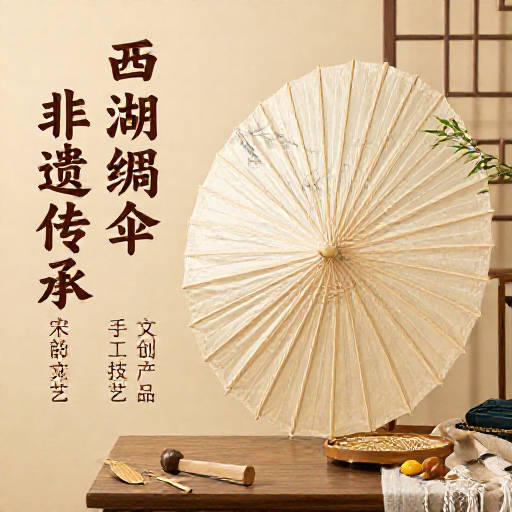


✅ 海报图片生成完成


In [9]:
# 从营销物料中提取海报提示词（这里使用示例提示词）
poster_prompt = f"""新中式风格海报，{global_context.shop_name}，
融合{global_context.features}元素，
{global_context.holiday}节日氛围，
高品质商业摄影风格，暖色调，细节精致"""

print("🖼️  正在生成海报图片...")
print(f"提示词：{poster_prompt[:100]}...")
print("-" * 60)

# 调用图像生成服务
poster_image = wanx_service.generate_poster(poster_prompt, size="512*512")

if poster_image:
    # 在 Jupyter 中显示图片
    from IPython.display import display
    display(poster_image)
    print("\n✅ 海报图片生成完成")
else:
    print("❌ 海报图片生成失败")

---

## 商家小助手 - 智能问答

In [10]:
# 模拟与商家小助手对话
questions = [
    "如何提升店铺的文化氛围？",
    "最近有什么适合的活动策划建议？",
    "怎样写更有吸引力的营销文案？"
]

print("🤖 商家小助手智能问答")
print("=" * 60)

for i, question in enumerate(questions, 1):
    print(f"\n【问题 {i}】{question}")
    print("-" * 60)

    context = global_context.to_prompt_context()

    system_prompt = f"""你是一位专业的文旅行业智能助手，服务于{context.get('shop_name', '未知店铺')}。

【店铺信息】
- 位置：{context.get('location', '未知')}
- 特色：{context.get('features', '无')}
- 今日天气：{context.get('weather', '未知')}
- 节假日：{context.get('holiday', '未知')}
- 目标客群：{context.get('target_audience', '普通游客')}

【你的职责】
1. 解答商家关于文旅运营的任何问题
2. 提供基于在地文化的专业建议
3. 语气亲切、专业、实用

【回答要求】
- 结合店铺实际情况给出建议
- 突出文化特色和在地资源
- 提供可执行的具体方案
- 避免空泛的理论
"""

    user_prompt = f"""{question}

请根据我的店铺情况，给出专业、实用的建议。"""

    response = llm_service.generate(system_prompt, user_prompt)
    print(response)

print("\n" + "=" * 60)
print("✅ 智能问答完成")

🤖 商家小助手智能问答

【问题 1】如何提升店铺的文化氛围？
------------------------------------------------------------
太好了！你的店铺——**西湖绸伞工艺坊**，坐落在**河坊街**，紧邻西湖、宋韵文化核心区，又恰逢**端午节**，本身就具备极强的文化基因和沉浸式体验潜力。结合“非遗传承+宋韵文化+手工技艺+文创产品”四大标签，我们可以从**空间、内容、互动、节庆**四个维度，做一套“可落地、可执行、有温度”的文化氛围提升方案：

---

🌿 **一、空间氛围：让“宋韵”在每一寸空间“活”起来**

1. **打造“宋式雅集”主题空间**  
   - 在入口处设置“宋人迎宾”屏风+香炉+茶具摆件，营造“踏青归家”之感。  
   - 用“宋画风”或“南宋市井图”做背景墙，搭配“宋瓷”“宋词”“宋锦”元素，强化视觉记忆。  
   - 陈列“宋朝市井生活”小道具（如宋代扇面、香囊、竹器），让顾客“身临其境”。

2. **雨天限定：小雨中的“宋韵雅集”**  
   - 今日小雨，可推出“**雨中赏伞·宋韵茶席**”活动：  
     - 提供“宋式茶点”+“雨天听雨”音乐+“古琴轻奏”（可与本地非遗琴师联动）  
     - 顾客可“手作一把小伞”或“体验折纸香囊”，雨中拍照打卡，生成“宋韵雨景”主题图。

3. **灯光+音效+气味：沉浸式感官体验**  
   - 用暖黄灯光+古琴/箫/古筝轻音乐，营造“江南夜雨”氛围。  
   - 香氛可选“沉香+檀香”（宋人常熏之），搭配“雨中茶席”更添韵味。

---

📜 **二、内容策划：让“非遗”在端午节“动”起来**

1. **端午节专属“非遗+民俗”体验**  
   - 推出“**端午·绸伞·非遗工坊**”主题体验：  
     - 顾客可参与“**手作端午香囊**”（用绸伞布料+艾草+香料）  
     - 或“**折纸龙舟**”+“**缠丝绳**”（象征端午驱邪）  
     - 附赠“**宋人端午图**”小册子+“**手写宋词**”（如“五月五日，粽香满巷”）

2. **“宋人过端午”沉浸式剧本体验**  
   - 设计“**穿越宋朝·过端午**”沉浸剧本：  
     - 顾客可扮演“南宋市井小贩”或“闺秀”，在

---
## 启动 Gradio GUI（推荐）

In [ ]:
# GUI 建议在本地端运行，经测试modelscope灵感无法在线显示GUI
import subprocess
import webbrowser
import time
from threading import Thread

def launch_gradio():
    """在后台启动 Gradio 应用"""
    print("🚀 正在启动 Gradio GUI...")
    print("📱 应用将在 http://localhost:7860 运行")

    # 启动 app.py
    subprocess.run([sys.executable, "app.py"])

# 询问用户是否启动 GUI
launch_gui = input("\n是否启动 Gradio GUI 界面？(y/n): ").strip().lower()

if launch_gui == 'y':
    print("\n" + "=" * 60)
    print("提示：")
    print("1. 浏览器将自动打开 http://localhost:7860")
    print("2. 如需停止服务，请在终端按 Ctrl+C")
    print("3. 或者访问下方显示的共享链接（如果启用）")
    print("=" * 60 + "\n")

    # 启动 Gradio（这会阻塞当前单元格）
    launch_gradio()
else:
    print("\n✅ Notebook 演示完成！")
    print("\n如需体验完整 GUI，可手动运行：")
    print("  python app.py")
    print("\n或在终端执行：")
    print("  start.bat  (Windows)")


提示：
1. 浏览器将自动打开 http://localhost:7860
2. 如需停止服务，请在终端按 Ctrl+C
3. 或者访问下方显示的共享链接（如果启用）

🚀 正在启动 Gradio GUI...
📱 应用将在 http://localhost:7860 运行
⏸️  按 Ctrl+C 可停止服务

